Data from the Energy Minimization process - we want to analyze the structural differences.

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import twistaly as tw

files_dir = "systems-mds"
twists = [0, 0.02, 0.035, 0.045]
utws = [[] for i in range(len(twists))]

for i, tws in enumerate(twists):
    u_filedir = files_dir + f"/twist{tws}-files"
    utws[i] = md.Universe(u_filedir + "/md_1.tpr", u_filedir + "/md_1_noPBC.xtc")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Atoms To Analyze ---
chains_tws = [[] for i in range(len(twists))]
proteins = [[] for i in range(len(twists))]
atom_gp = "name CA"

for i in range(len(twists)):
    proteins[i] = utws[i].select_atoms("protein")
    #atom_group = protein.select_atoms(atom_gp) 
    chains_tws[i] = proteins[i].fragments

### Evolution of Structure

In [3]:
# --- Time Data ---
tf = 25 # ns
time = np.linspace(0, 25, len(utws[0].trajectory))

key_times = [0, 10, 20, 25]
idx_kt = [np.where(time == kt)[0] for kt in key_times]

# --- Prot Data ---
num_mol = int(len(chains_tws[0])/3)

In [4]:
# --- Evaluation in Key Points ---
psi = [[[] for i in range(len(twists))] for i in range(len(key_times))] # time, twist, mol
rad = [[[] for i in range(len(twists))] for i in range(len(key_times))]
r2 = [[[] for i in range(len(twists))] for i in range(len(key_times))]

for i in range(len(key_times)):
    # --- SET THE FRAME to the time ---
    id_time = idx_kt[i]
    this_time = time[idx_kt[i]]
    for u in utws:
        u.trajectory._read_frame(id_time)

    # --- Compute Psis ---
    for j, chains in enumerate(chains_tws):
        com = proteins[j].center_of_mass()
        psi_u = np.zeros(num_mol)
        rad_u = np.zeros(num_mol)
        r2_u = np.zeros(num_mol)

        for mol in range(num_mol):
            mol_coords = (chains[3*mol].select_atoms(atom_gp) + chains[3*mol + 1].select_atoms(atom_gp)+ chains[3*mol + 2].select_atoms(atom_gp)).positions - np.array([com[0], com[1], 0.0])
            
            # --- Compute Psi ---
            mol_coords_filt = tw.remove_ends(0.5, mol_coords) / 10
            r, phi, z = tw.cyl_proj(mol_coords_filt)
            arc = r*phi

            tau, _, dr2 = tw.ortreglinfit(z, arc)
            psi_u[mol] = np.rad2deg(np.atan(tau))
            # psi_u[mol] = np.rad2deg(np.atan(abs(tau)))
            rad_u[mol] = np.mean(r)
            r2_u[mol] = dr2 # Similar to R^2


        psi[i][j] = psi_u
        rad[i][j] = rad_u
        r2[i][j] = r2_u

    # print(utws[0].trajectory.time)
    # print(id_time)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/MDAnalysis/coordinates/XDR.py:299: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self._xdr.seek(i)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/MDAnalysis/coordinates/XTC.py:166: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ts.frame = self._frame


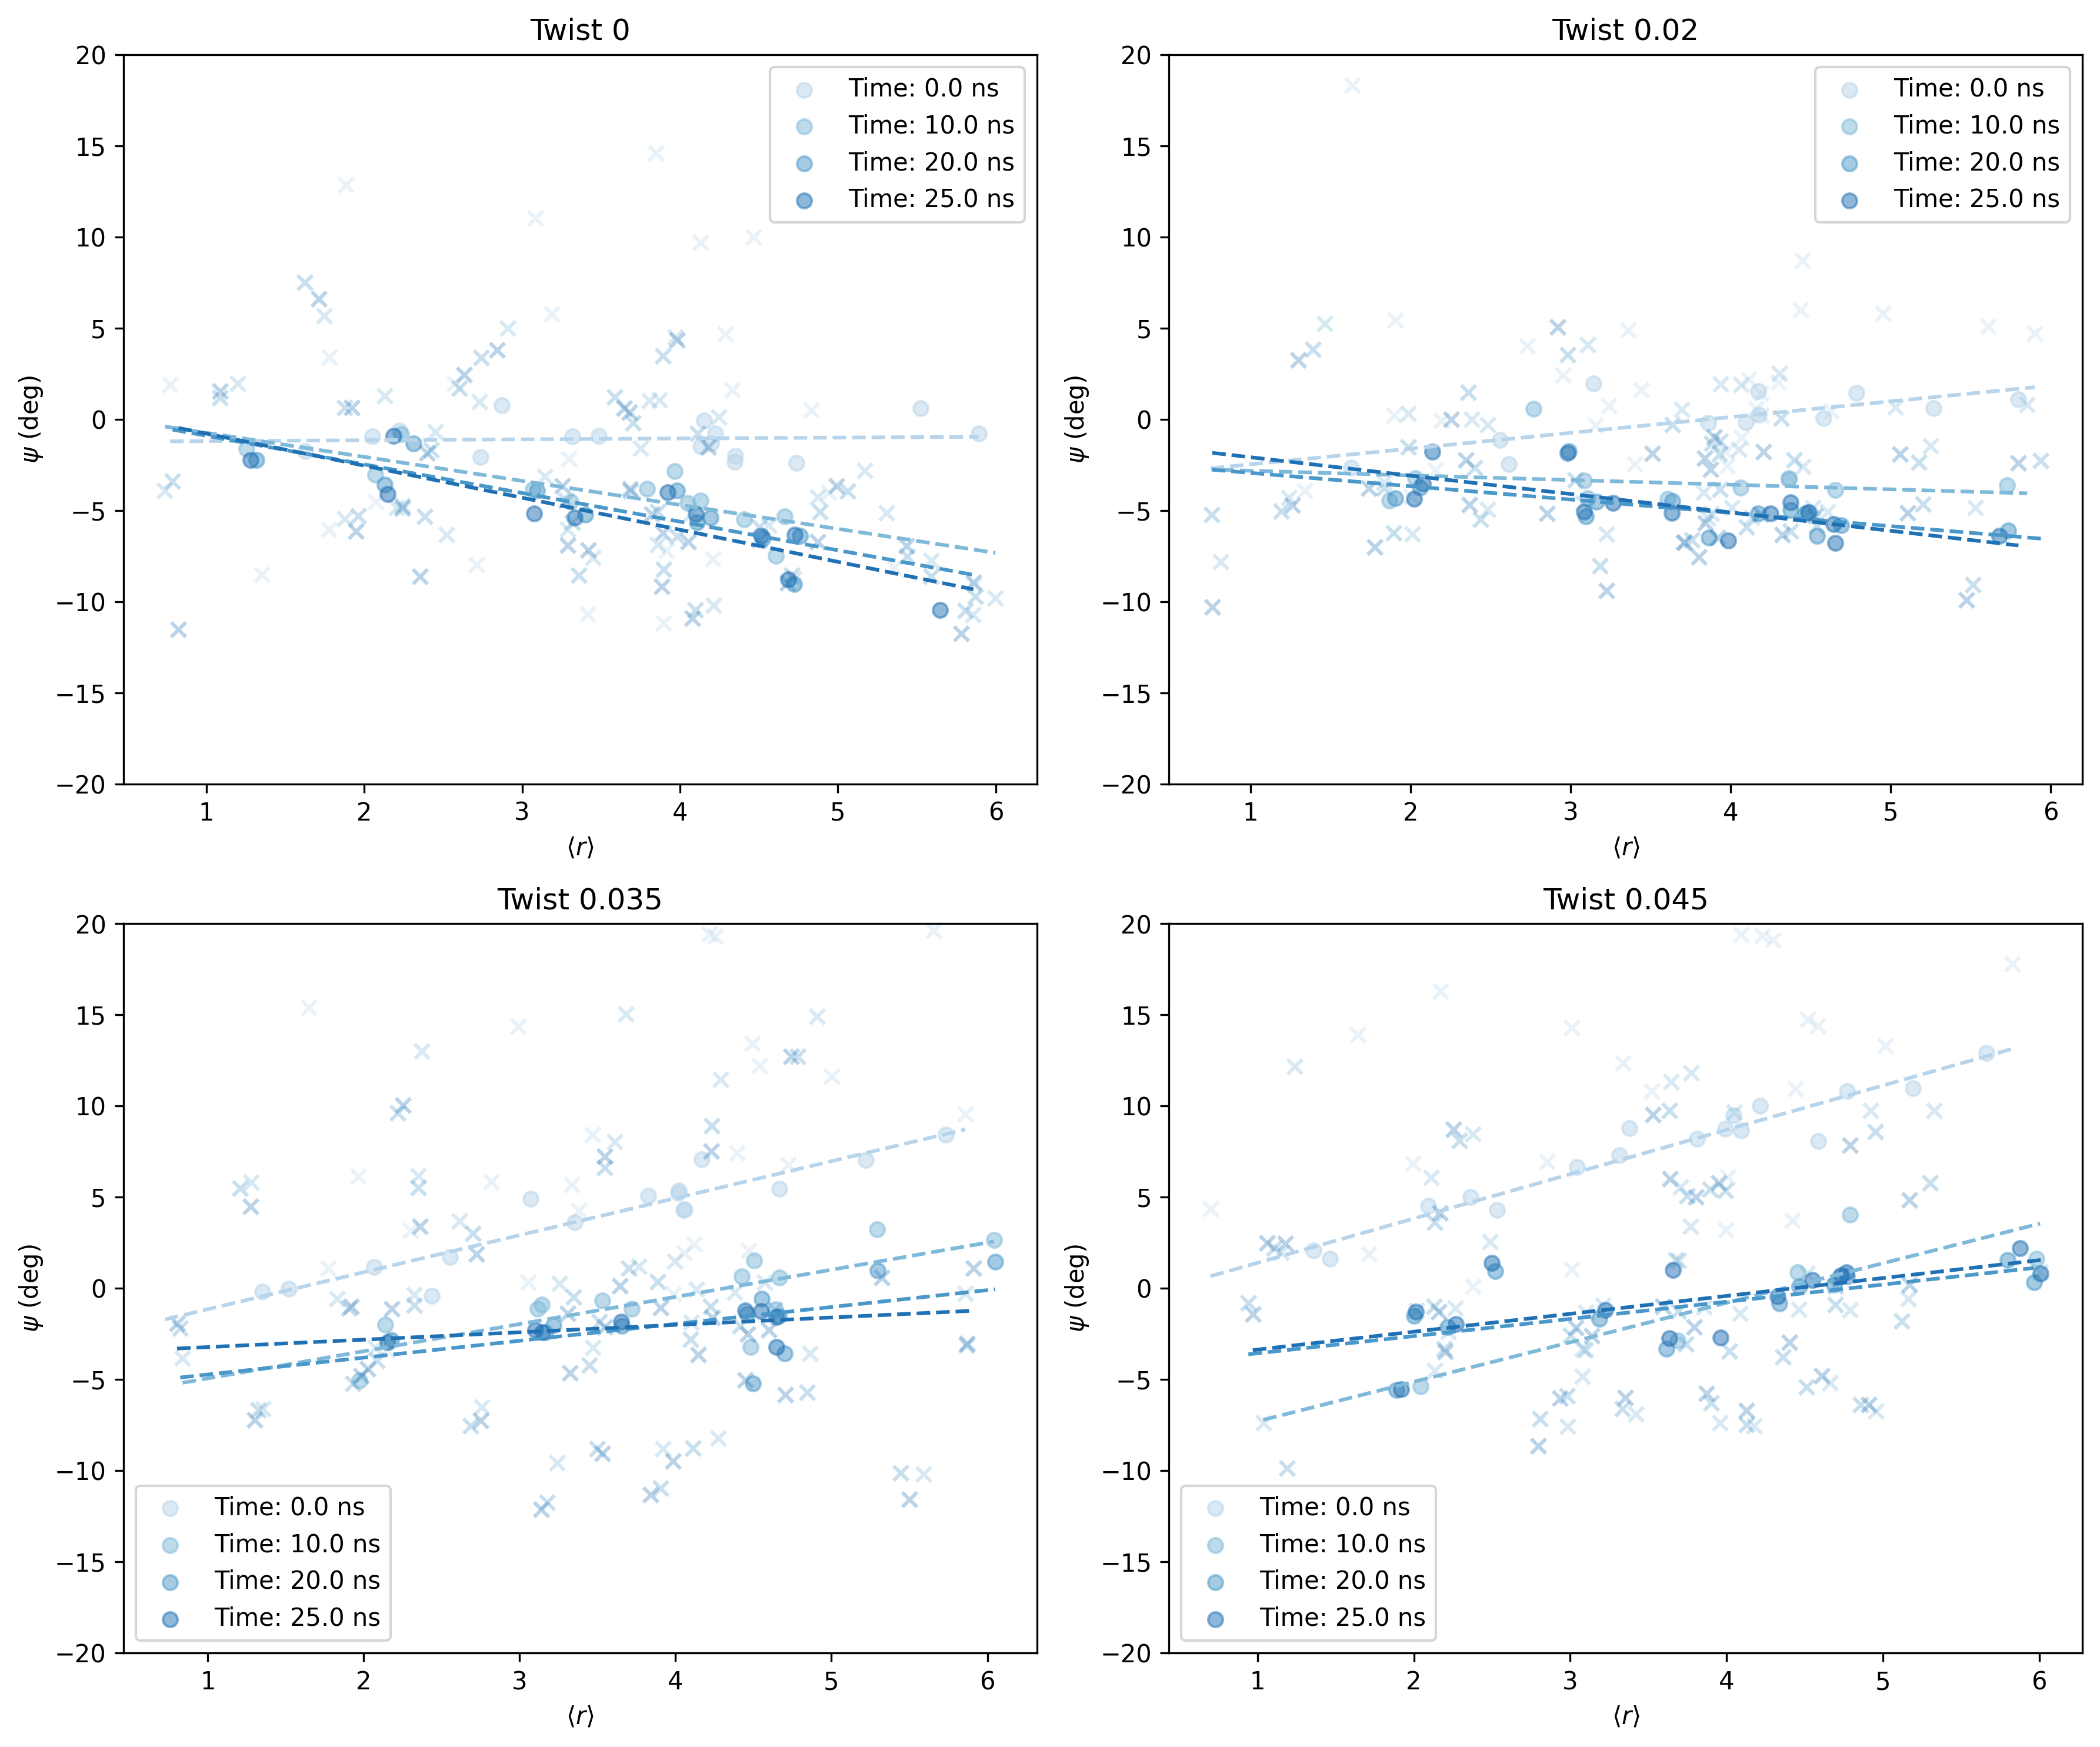

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(12,10), dpi=300)
cmap = plt.cm.Blues 
colors = ["b", "r", "g", "y"]
threshold = 0.2 # Variance - Lower, Better

for i in range(len(key_times)):
    this_time = time[idx_kt[i]][0]
    color = cmap(0.3 + 0.15 * i)
    #color = colors[i]

    for j in range(len(twists)):
        jb = bin(j)
        if jb[-2] == 'b':
            id1 = 0
        else: id1 = int(jb[-2])
        id2 = int(jb[-1])

        psi_iter = np.array(psi[i][j])
        rad_iter = np.array(rad[i][j])
        r2_iter = np.array(r2[i][j])

        # Masking
        mask = (r2_iter < threshold)

        psi_gr2 = psi_iter[mask]
        rad_gr2 = rad_iter[mask]

        psi_br2 = psi_iter[~mask]
        rad_br2 = rad_iter[~mask]

        # --- Classification of Data ---
        ax[id1,id2].scatter(rad_gr2, psi_gr2, color=color, edgecolor=color, alpha=0.5, label=f"Time: {this_time} ns")
        ax[id1,id2].scatter(rad_br2, psi_br2, color=color, alpha=0.3, marker="x")

        # Fit and plot
        m, b = np.polyfit(rad_gr2, psi_gr2, 1)
        r_plot = np.linspace(min(rad[i][j]), max(rad[i][j]), 100)
        ax[id1,id2].plot(r_plot, m*r_plot + b, linestyle='dashed', color=color)

for j in range(len(twists)):
    jb = bin(j)
    if jb[-2] == 'b':
        id1 = 0
    else:
        id1 = int(jb[-2])
    id2 = int(jb[-1])

    ax[id1,id2].set_title(f"Twist {twists[j]}")
    ax[id1,id2].set_ylim(-20, 20)
    ax[id1,id2].set_xlabel(r"$\langle r \rangle$")
    ax[id1,id2].set_ylabel(r"$\psi$ (deg)")
    ax[id1,id2].legend()

plt.tight_layout()
plt.show()

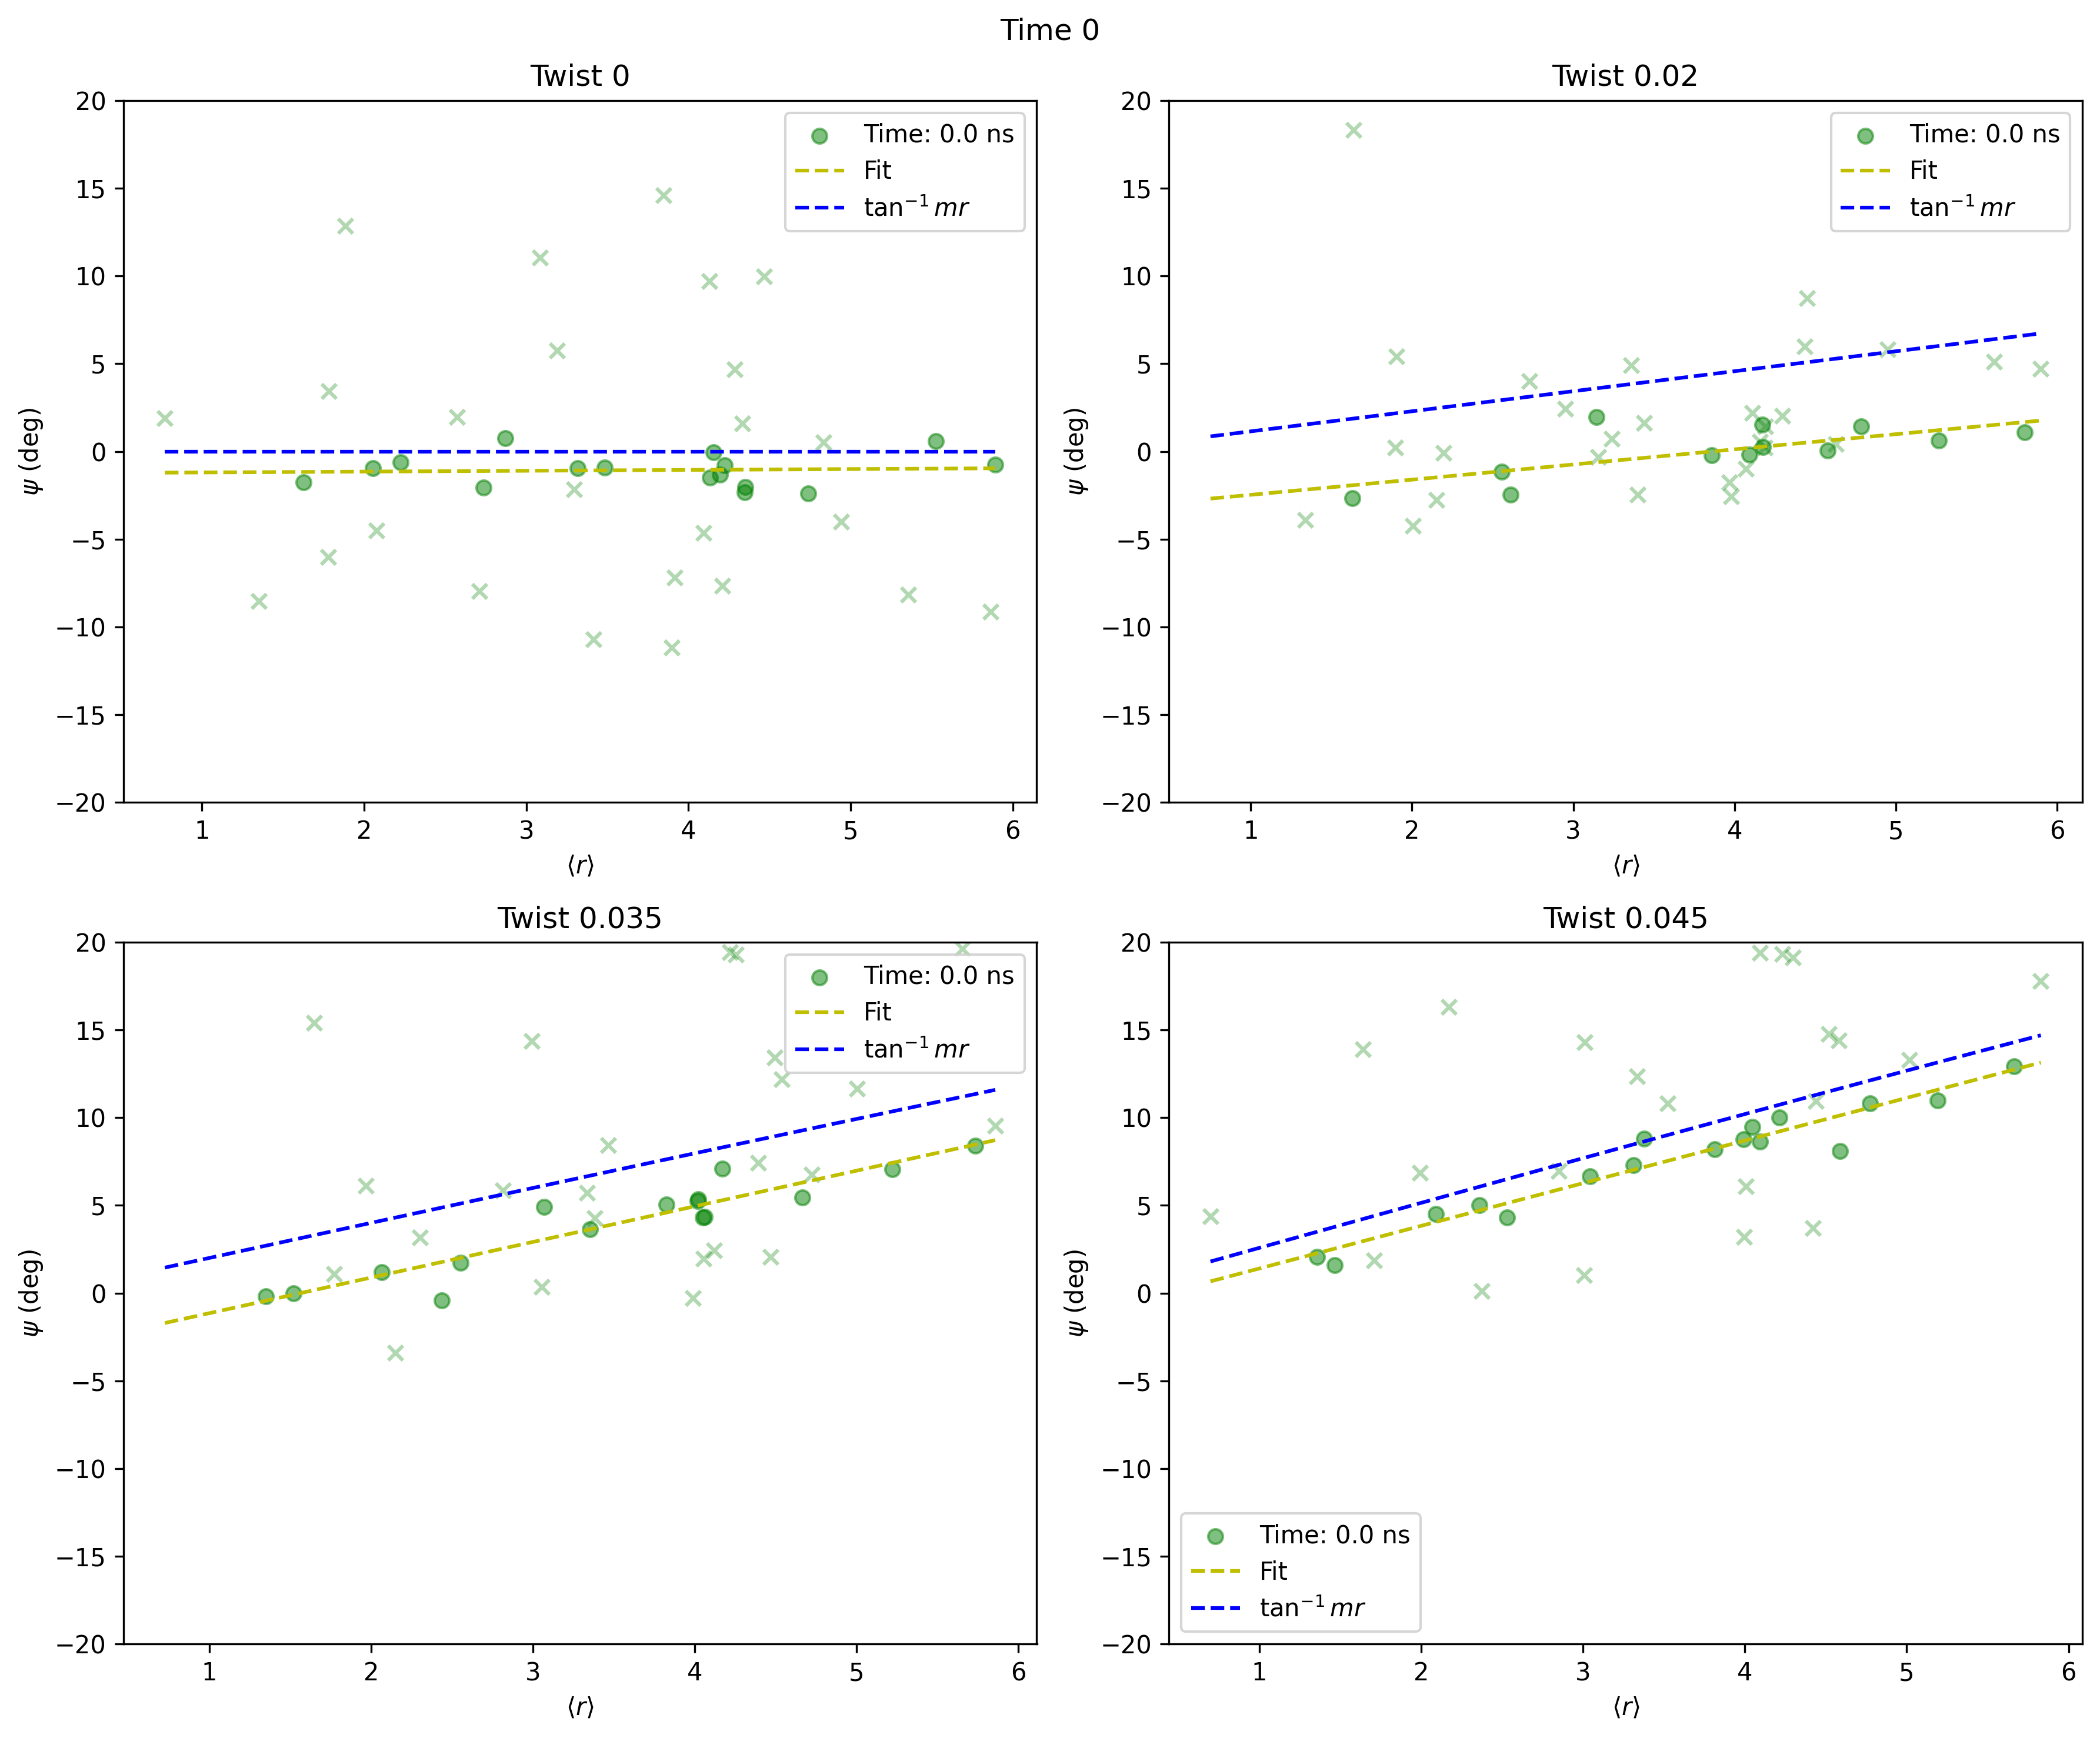

In [6]:
# --- TIME 0: Comparison with Function tan^-1 ---
fig, ax = plt.subplots(2, 2, figsize=(12,10), dpi=300)
colors = ["b", "r", "g", "y"]

this_time = time[idx_kt[0]][0]
#color = cmap(0.3 + 0.15 * i)
color = colors[2]

for j in range(len(twists)):
    jb = bin(j)
    if jb[-2] == 'b':
        id1 = 0
    else: id1 = int(jb[-2])
    id2 = int(jb[-1])

    psi_iter = np.array(psi[0][j])
    rad_iter = np.array(rad[0][j])
    r2_iter = np.array(r2[0][j])

    mask = (r2_iter < threshold)

    psi_gr2 = psi_iter[mask]
    rad_gr2 = rad_iter[mask]

    psi_br2 = psi_iter[~mask]
    rad_br2 = rad_iter[~mask]

    # --- Classification of Data ---
    ax[id1,id2].scatter(rad_gr2, psi_gr2, color=color, edgecolor=color, alpha=0.5, label=f"Time: {this_time} ns")
    ax[id1,id2].scatter(rad_br2, psi_br2, color=color, alpha=0.3, marker="x")

    # Fit and plot
    m, b = np.polyfit(rad_gr2, psi_gr2, 1)
    r_plot = np.linspace(min(rad_iter), max(rad_iter), 100)
    ax[id1,id2].plot(r_plot, m*r_plot + b, linestyle='dashed', color="y", label="Fit")

    ax[id1,id2].plot(r_plot, np.rad2deg(np.atan(twists[j]*r_plot)), linestyle='dashed', color="b", label=r"$\tan^{-1}mr$")

for j in range(len(twists)):
    jb = bin(j)
    if jb[-2] == 'b':
        id1 = 0
    else:
        id1 = int(jb[-2])
    id2 = int(jb[-1])

    ax[id1,id2].set_title(f"Twist {twists[j]}")
    ax[id1,id2].set_ylim(-20, 20)
    ax[id1,id2].set_xlabel(r"$\langle r \rangle$")
    ax[id1,id2].set_ylabel(r"$\psi$ (deg)")
    ax[id1,id2].legend()

plt.suptitle("Time 0")
plt.tight_layout()
plt.show()

### Evolution of Slope of Function

In [ ]:
slope = [np.zeros(len(time)) for i in range(len(twists))] # Each of the configurations evolution

for i in range(len(time)):
    # --- SET THE FRAME to the time ---
    for u in utws:
        u.trajectory._read_frame(i) # Move to TimeStep

    # --- Compute Psis ---
    for j, chains in enumerate(chains_tws):
        com = proteins[j].center_of_mass()
        psi_u = np.zeros(num_mol)
        rad_u = np.zeros(num_mol)
        r2_u = np.zeros(num_mol)

        for mol in range(num_mol):
            mol_coords = (chains[3*mol].select_atoms(atom_gp) + chains[3*mol + 1].select_atoms(atom_gp)+ chains[3*mol + 2].select_atoms(atom_gp)).positions - np.array([com[0], com[1], 0.0])
            
            # --- Compute Psi ---
            mol_coords_filt = tw.remove_ends(0.5, mol_coords) / 10
            r, phi, z = tw.cyl_proj(mol_coords_filt)
            arc = r*phi

            tau, _, dr2 = tw.ortreglinfit(z, arc)
            psi_u[mol] = np.rad2deg(np.atan(tau))
            rad_u[mol] = np.mean(r)
            r2_u[mol] = dr2 # Similar to R^2
            
        # --- Filtering and Fit ---
        mask = (r2_u < threshold)
        psi_gr2 = psi_u[mask]
        rad_gr2 = rad_u[mask]

        m, _ = np.polyfit(rad_gr2, psi_gr2, 1)

        # --- Save Slope ---
        slope[j][i] = m

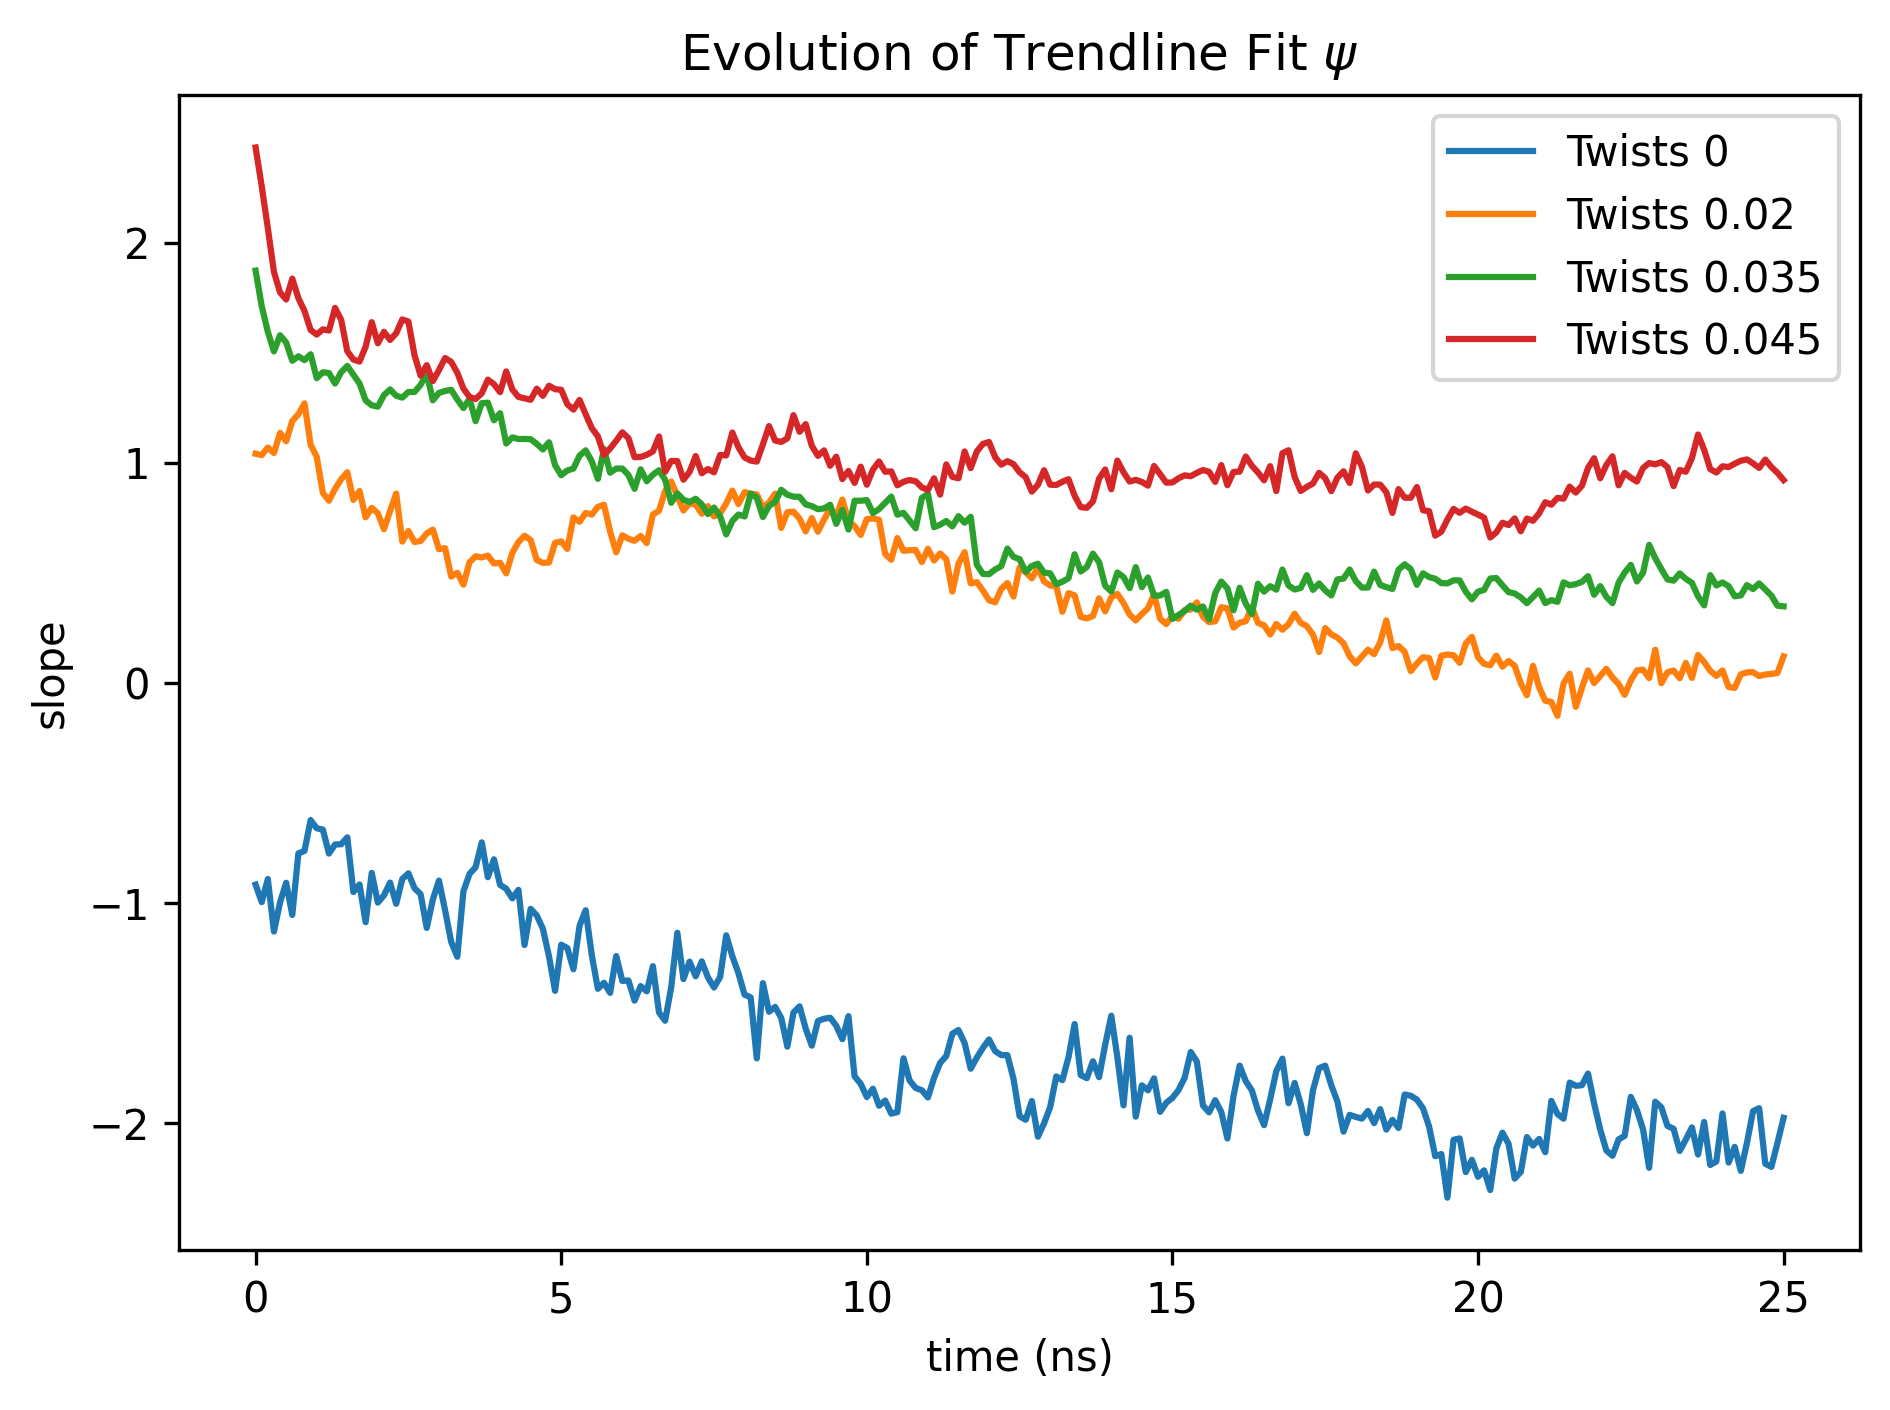

In [8]:
plt.figure(dpi=300)

for p in range(len(twists)):
    slope_p = slope[p]
    plt.plot(time, slope_p, label=f"Twists {twists[p]}")

plt.xlabel("time (ns)")
plt.ylabel("slope")
plt.title(r"Evolution of Trendline Fit $\psi$")
plt.legend()

plt.tight_layout()
plt.show()